## Q-Commerce Analysis

In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline
#%pip install scikit-learn
import sklearn

#%pip install plotly

In [95]:
df = pd.read_csv('quick_commerce_data_raw.csv')

In [96]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8


In [97]:
#dataset structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Order_ID                 1000000 non-null  int64  
 1   Company                  1000000 non-null  object 
 2   City                     948000 non-null   object 
 3   Customer_Age             1000000 non-null  int64  
 4   Order_Value              1000000 non-null  float64
 5   Delivery_Time_Min        1000000 non-null  float64
 6   Distance_Km              1000000 non-null  float64
 7   Items_Count              965000 non-null   float64
 8   Product_Category         1000000 non-null  object 
 9   Payment_Method           1000000 non-null  object 
 10  Customer_Rating          953000 non-null   float64
 11  Discount_Applied         1000000 non-null  int64  
 12  Delivery_Partner_Rating  895863 non-null   float64
dtypes: float64(6), int64(3), object(4)
memory u

In [98]:
df.describe()  # statistical summary

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,965000.000000,953000.000000,1000000.000000,895863.000000
mean,1.500000e+06,38.470387,571.643584,16.452412,7.750231,9.998317,3.042072,0.400883,3.749257
std,2.886753e+05,12.118520,382.784520,6.257172,4.186665,5.478725,1.186872,0.490078,0.722121
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.250001e+06,28.000000,287.840150,12.368000,4.130000,5.000000,2.000000,0.000000,3.100000
50%,1.500000e+06,38.000000,531.324600,16.342000,7.740000,10.000000,3.000000,0.000000,3.700000
75%,1.750000e+06,49.000000,796.182500,20.196000,11.380000,15.000000,4.000000,1.000000,4.400000
max,2.000000e+06,59.000000,13877.325000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [99]:
#checking missing value

df.isna().sum()

Order_ID                        0
Company                         0
City                        52000
Customer_Age                    0
Order_Value                     0
Delivery_Time_Min               0
Distance_Km                     0
Items_Count                 35000
Product_Category                0
Payment_Method                  0
Customer_Rating             47000
Discount_Applied                0
Delivery_Partner_Rating    104137
dtype: int64

In [100]:
# to see where we have missin values

df[df.isna().any(axis = 1)]

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
6,1000007,Blinkit,Bengluru,37,516.86480,18.476,12.46,19.0,Snacks,Debit Card,2.8,0,NaN
17,1000018,Zepto,Delhi,23,1041.42975,5.000,14.74,18.0,Snacks,Wallet,NaN,1,NaN
21,1000022,Blinkit,NaN,41,716.89860,17.804,11.34,7.0,Beverages,Credit Card,2.7,1,3.6
22,1000023,Jio Mart,Delhi,48,50.00000,8.498,0.83,3.0,Snacks,Cash on Delivery,3.1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999966,1999967,Dunzo,NaN,39,783.89250,18.820,14.70,NaN,Household,Wallet,3.1,1,4.9
999975,1999976,Amazon Now,Bengluru,34,515.89380,21.294,10.49,10.0,Fruits & Vegetables,Wallet,NaN,1,3.0
999981,1999982,Amazon Now,NaN,33,939.34470,21.080,11.80,18.0,Dairy,Wallet,3.2,1,4.4
999983,1999984,Swiggy Instamart,Hyderabad,42,50.00000,13.386,2.31,2.0,Groceries,Wallet,NaN,0,3.2


In [101]:
df[df.isna().all(axis = 1)]

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating


In [102]:
#Removing rows having null values in respect to city

df = df.dropna(subset = ['City'])

In [103]:
df.shape

(948000, 13)

In [104]:
df.isna().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                33228
Product_Category               0
Payment_Method                 0
Customer_Rating            44575
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

In [105]:
x = df['Items_Count'].mode() #mode of Items Count
x

0    19.0
Name: Items_Count, dtype: float64

In [106]:
df['Items_Count']=df['Items_Count'].fillna(x[0])

In [107]:
# filling Nan  for rating on group basis

In [108]:
df['Customer_Rating']=df.groupby('Company')['Customer_Rating'].transform(lambda x: x.fillna(x.mean()))

In [109]:
df.isnull().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                    0
Product_Category               0
Payment_Method                 0
Customer_Rating                0
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

In [110]:
df['Delivery_Partner_Rating']=df.groupby('Delivery_Time_Min')['Delivery_Partner_Rating'].transform(lambda y: y.fillna(y.mean()))

In [111]:
df.isnull().sum()

Order_ID                    0
Company                     0
City                        0
Customer_Age                0
Order_Value                 0
Delivery_Time_Min           0
Distance_Km                 0
Items_Count                 0
Product_Category            0
Payment_Method              0
Customer_Rating             0
Discount_Applied            0
Delivery_Partner_Rating    76
dtype: int64

In [112]:
df['Delivery_Partner_Rating'] = df['Delivery_Partner_Rating'].fillna(df['Delivery_Partner_Rating'].mean())

In [113]:
df.isnull().sum()

Order_ID                   0
Company                    0
City                       0
Customer_Age               0
Order_Value                0
Delivery_Time_Min          0
Distance_Km                0
Items_Count                0
Product_Category           0
Payment_Method             0
Customer_Rating            0
Discount_Applied           0
Delivery_Partner_Rating    0
dtype: int64

<Axes: >

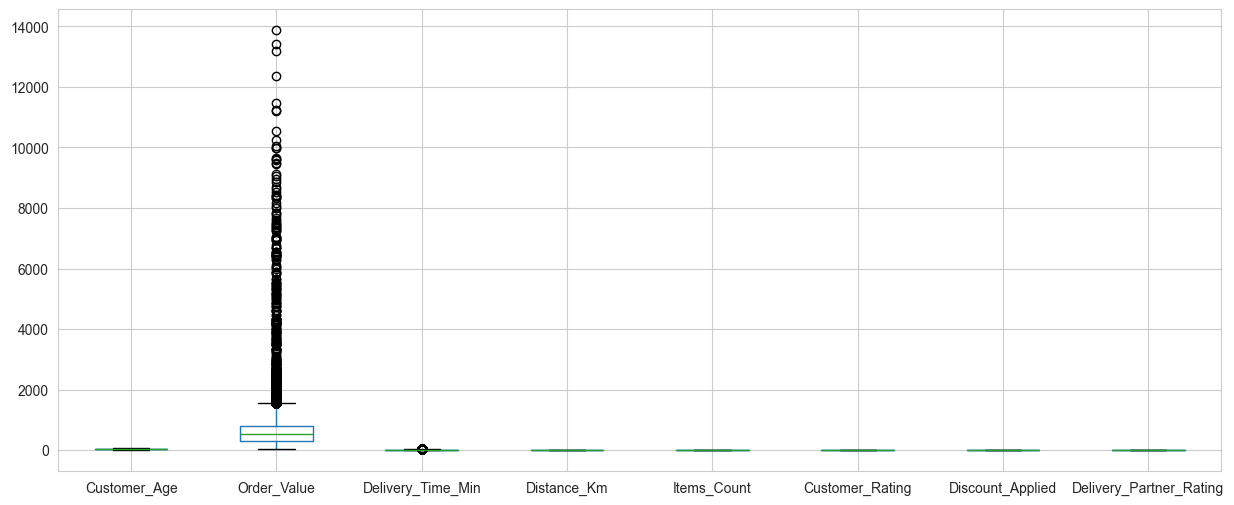

In [114]:
plt.figure(figsize = (15, 6))

df.drop(columns = ['Order_ID']).boxplot()

In [115]:
df=df[df['Order_Value']<=2500]

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 947752 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  int64  
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  float64
 5   Delivery_Time_Min        947752 non-null  float64
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  float64
 8   Product_Category         947752 non-null  object 
 9   Payment_Method           947752 non-null  object 
 10  Customer_Rating          947752 non-null  float64
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  float64
dtypes: float64(6), int64(3), object(4)
memory usage: 101.2+ MB


<Axes: >

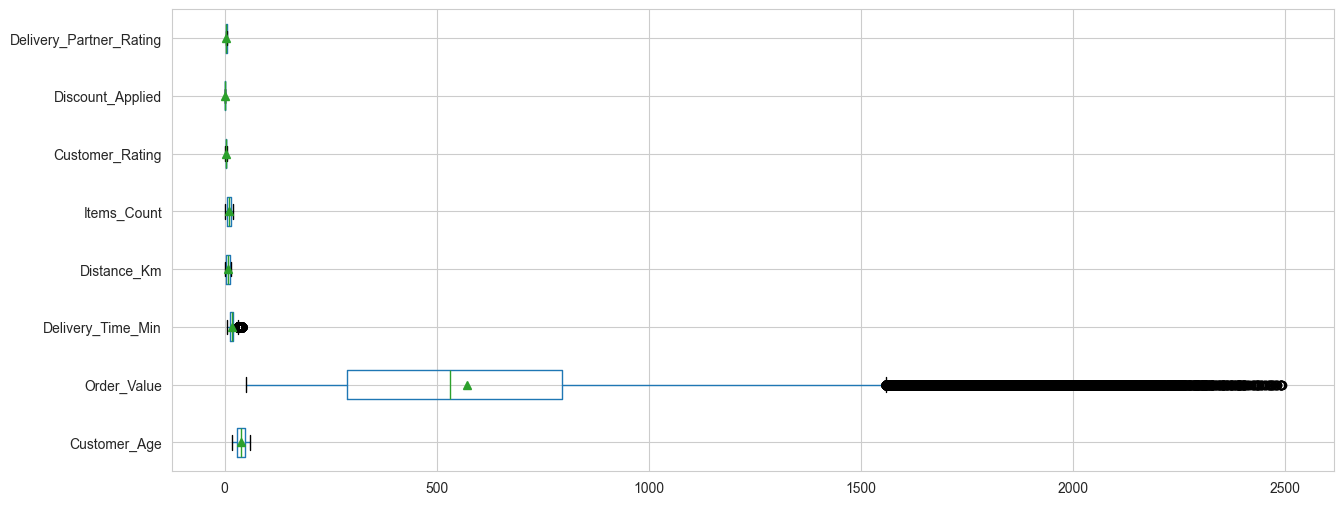

In [117]:
plt.figure(figsize = (15, 6))

df.drop(columns = ['Order_ID']).boxplot(vert = False, showmeans = True)


In [118]:
df['Order_ID'] = df['Order_ID'].astype(str)

In [119]:
type(df['Order_ID'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 947752 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  object 
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  float64
 5   Delivery_Time_Min        947752 non-null  float64
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  float64
 8   Product_Category         947752 non-null  object 
 9   Payment_Method           947752 non-null  object 
 10  Customer_Rating          947752 non-null  float64
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  float64
dtypes: float64(6), int64(2), object(5)
memory usage: 101.2+ MB


In [120]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,19.0,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8


In [121]:
df['Order_Value'] = np.round(df['Order_Value'], 0)

In [122]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.0,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.0,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1212.0,16.910,4.85,19.0,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.0,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.0,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8


In [123]:
df['Order_Value'] = df['Order_Value'].astype(int)
df['Items_Count'] = df['Items_Count'].astype(int)

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 947752 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  object 
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  int64  
 5   Delivery_Time_Min        947752 non-null  float64
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  int64  
 8   Product_Category         947752 non-null  object 
 9   Payment_Method           947752 non-null  object 
 10  Customer_Rating          947752 non-null  float64
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  float64
dtypes: float64(4), int64(4), object(5)
memory usage: 101.2+ MB


In [125]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19.182,11.97,12,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007,19.644,12.74,10,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1212,16.910,4.85,19,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179,5.864,6.44,2,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586,12.470,2.45,13,Household,Wallet,3.7,0,4.8


## Saved the cleaned data file

In [125]:
new_path = r'C:\Users\user\Desktop\data-analysis project\Q-commerce/Cleaned_Q_commerce_Data.csv'

In [126]:
df.to_csv(new_path, index = False)

In [2]:
df = pd.read_csv('Cleaned_Q_Commerce_Data.csv')
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19.182,11.97,12,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007,19.644,12.74,10,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1212,16.910,4.85,19,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179,5.864,6.44,2,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586,12.470,2.45,13,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
947747,1999996,Big Basket,Mumbai,48,72,17.806,3.01,19,Fruits & Vegetables,Wallet,4.2,0,2.8
947748,1999997,Swiggy Instamart,Mumbai,33,1510,18.306,10.51,9,Beverages,Debit Card,4.1,1,3.5
947749,1999998,Jio Mart,Noida,29,637,17.590,2.65,6,Groceries,Cash on Delivery,3.4,0,4.6
947750,1999999,Dunzo,Pune,42,1103,12.656,7.76,12,Snacks,Wallet,4.0,1,4.5


# Data analysis 

### Logistics & Operational Excellence

#### Q1. How fast are we delivering on average?

In [3]:
avg_dt = round(df['Delivery_Time_Min'].mean(), 2)

In [4]:
avg_dt

np.float64(16.5)

#### Q2. Is speed consistent across distances?

In [5]:
speed_consistency = round(df['Distance_Km'].mean()/df['Delivery_Time_Min'].mean(), 2)

In [6]:
speed_consistency

np.float64(0.47)

#### Q3. Which Quick commerce company has the highest revenue

In [7]:
company_revenue = df.groupby('Company')['Order_Value'].sum()

In [8]:
company_revenue.sort_values()

Company
Jio Mart            57112860
Dunzo               64007579
Amazon Now          65832504
Flipkart Minutes    66998289
Big Basket          67884762
Zepto               70339672
Blinkit             72499575
Swiggy Instamart    76407756
Name: Order_Value, dtype: int64

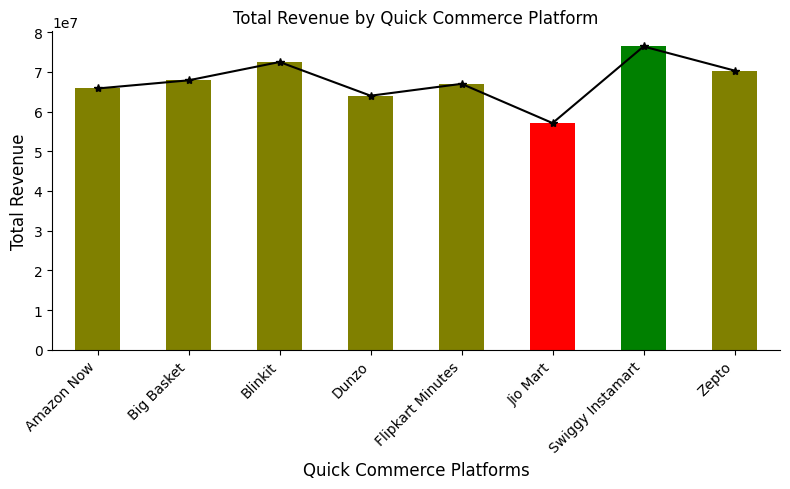

In [9]:
#bar and line chart

plt.figure(figsize = (8, 5))

max_val = company_revenue.max()
min_value = company_revenue.min()

colors = ['green' if val == max_val else
         'red' if val == min_value else
         'olive'
         for val in company_revenue]

company_revenue.plot( kind = 'bar', color = colors)
company_revenue.plot(kind = 'line', color = 'black', marker = '*')

plt.xlabel('Quick Commerce Platforms', fontsize = 12)
plt.ylabel('Total Revenue', fontsize = 12)
plt.title('Total Revenue by Quick Commerce Platform')
plt.xticks(rotation = 45, ha = "right")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.show()

#### Q4. Which platform has the highest average order value

In [10]:
df.groupby('Company')['Order_Value'].mean()

Company
Amazon Now          557.510429
Big Basket          575.065542
Blinkit             609.819198
Dunzo               540.317053
Flipkart Minutes    563.176472
Jio Mart            482.914592
Swiggy Instamart    644.927250
Zepto               593.258314
Name: Order_Value, dtype: float64

In [11]:
AOV = df.groupby('Company')['Order_Value'].mean().sort_values()

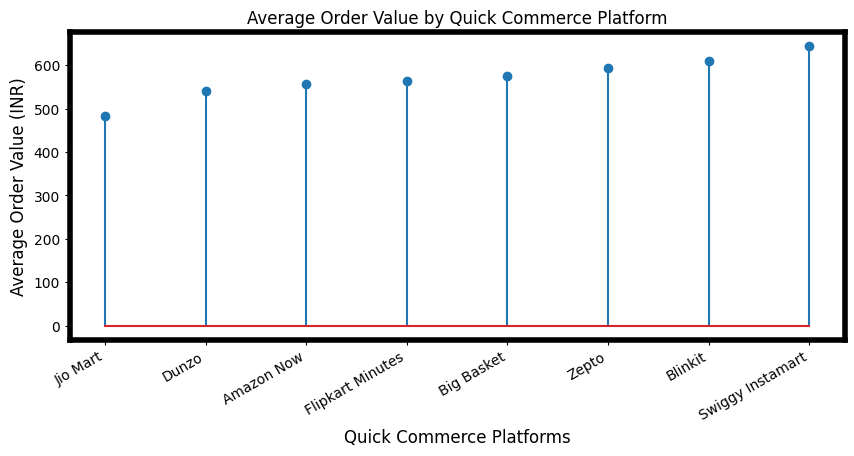

In [12]:
plt.figure(figsize = (10, 4))

plt.stem(AOV.index, AOV.values)
plt.xlabel('Quick Commerce Platforms', fontsize = 12)
plt.ylabel('Average Order Value (INR)', fontsize = 12)
plt.title('Average Order Value by Quick Commerce Platform')
plt.xticks(rotation = 30, ha = "right")

ax = plt.gca()
ax.spines['top'].set_linewidth(4)
ax.spines['right'].set_linewidth(4)
ax.spines['bottom'].set_linewidth(4)
ax.spines['left'].set_linewidth(4)

plt.show()

#### Q5. How does Customer Rating vary across platforms?

In [13]:
ACR = df.groupby('Company')['Customer_Rating'].mean().sort_values()
ACR

Company
Dunzo               2.456282
Jio Mart            2.816268
Amazon Now          2.907280
Flipkart Minutes    3.015536
Big Basket          3.100922
Zepto               3.203314
Swiggy Instamart    3.284068
Blinkit             3.556582
Name: Customer_Rating, dtype: float64

<Figure size 1000x400 with 0 Axes>

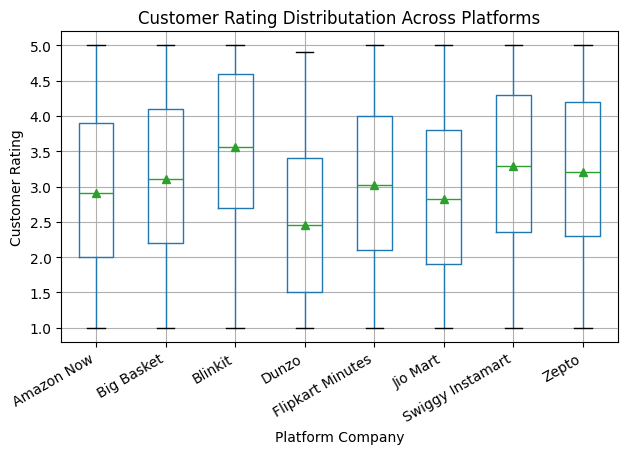

In [14]:
plt.figure(figsize = (10, 4))

df.boxplot(column = 'Customer_Rating', by = 'Company', showmeans = True)

plt.suptitle("")

plt.title("Customer Rating Distributation Across Platforms")
plt.xlabel("Platform Company")
plt.ylabel("Customer Rating")
plt.xticks(rotation = 30, ha = 'right')

plt.tight_layout()
plt.show()

In [15]:
df['Rounded_Rating'] = df['Customer_Rating'].round().astype(int)
GR = df.groupby(['Company', 'Rounded_Rating']).size().unstack(fill_value = 0)

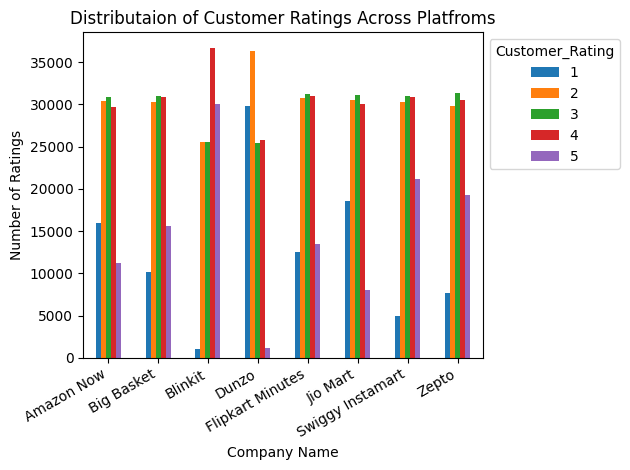

In [16]:
GR.plot(kind = 'bar')

plt.xlabel('Company Name')
plt.ylabel('Number of Ratings')
plt.title("Distributaion of Customer Ratings Across Platfroms")

plt.legend(title = 'Customer_Rating', bbox_to_anchor = (1,1), loc = 'upper left')
plt.xticks(rotation = 30, ha = 'right')
plt.tight_layout()
plt.show()

#### Q6. Does Delivery Time affects the Delivery partner rating?

In [17]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Rounded_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19.182,11.97,12,Dairy,Wallet,2.1,1,3.2,2
1,1000002,Flipkart Minutes,Amritsar,56,1007,19.644,12.74,10,Snacks,Cash on Delivery,2.3,0,3.2,2
2,1000003,Flipkart Minutes,Mumbai,18,1212,16.910,4.85,19,Personal Care,Cash on Delivery,3.3,0,3.8,3
3,1000004,Swiggy Instamart,Delhi,23,1179,5.864,6.44,2,Dairy,Credit Card,5.0,1,5.0,5
4,1000005,Dunzo,Mumbai,44,586,12.470,2.45,13,Household,Wallet,3.7,0,4.8,4


In [18]:
df['Delivery_Time_Min'].mean()

np.float64(16.50206995289907)

In [19]:
df['Delivery_Partner_Rating'].mean()

np.float64(3.749173250933465)

In [20]:
df['Round_delivery_time'] = df['Delivery_Time_Min'].round().astype(int)
x = df.groupby('Round_delivery_time')['Delivery_Partner_Rating'].mean()

In [21]:
df['Delivery_Time_Min'].corr(df['Delivery_Partner_Rating'])

np.float64(-0.0009691810259054333)

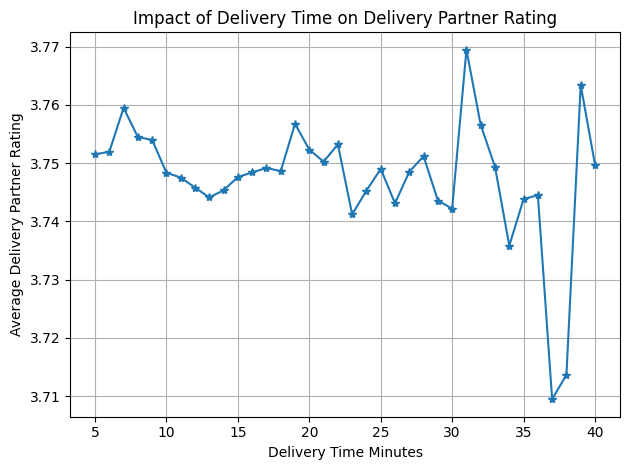

In [22]:
x.plot(marker = '*')

plt.xlabel('Delivery Time Minutes')
plt.ylabel('Average Delivery Partner Rating')
plt.title('Impact of Delivery Time on Delivery Partner Rating')
plt.grid(True)

plt.tight_layout()
plt.show()

In [23]:
df['Delivery_Time_Bucket'] = pd.cut(df['Delivery_Time_Min'], 
       bins = (0, 10, 20, 30, 40, 50),
       labels = ("Very Fast Delivery", "Fast Delivery", "Normal Delivery", "Slow Delivery", "Very Slow Delivery"))

In [24]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Rounded_Rating,Round_delivery_time,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19.182,11.97,12,Dairy,Wallet,2.1,1,3.2,2,19,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,19.644,12.74,10,Snacks,Cash on Delivery,2.3,0,3.2,2,20,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,16.910,4.85,19,Personal Care,Cash on Delivery,3.3,0,3.8,3,17,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,5.864,6.44,2,Dairy,Credit Card,5.0,1,5.0,5,6,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12.470,2.45,13,Household,Wallet,3.7,0,4.8,4,12,Fast Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947747,1999996,Big Basket,Mumbai,48,72,17.806,3.01,19,Fruits & Vegetables,Wallet,4.2,0,2.8,4,18,Fast Delivery
947748,1999997,Swiggy Instamart,Mumbai,33,1510,18.306,10.51,9,Beverages,Debit Card,4.1,1,3.5,4,18,Fast Delivery
947749,1999998,Jio Mart,Noida,29,637,17.590,2.65,6,Groceries,Cash on Delivery,3.4,0,4.6,3,18,Fast Delivery
947750,1999999,Dunzo,Pune,42,1103,12.656,7.76,12,Snacks,Wallet,4.0,1,4.5,4,13,Fast Delivery


In [25]:
bucket_avg = df.groupby('Delivery_Time_Bucket')['Delivery_Partner_Rating'].mean()

bucket_avg

C:\Users\user\AppData\Local\Temp\ipykernel_15688\1409831079.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_avg = df.groupby('Delivery_Time_Bucket')['Delivery_Partner_Rating'].mean()


Delivery_Time_Bucket
Very Fast Delivery    3.753362
Fast Delivery         3.748447
Normal Delivery       3.748313
Slow Delivery         3.748679
Very Slow Delivery         NaN
Name: Delivery_Partner_Rating, dtype: float64

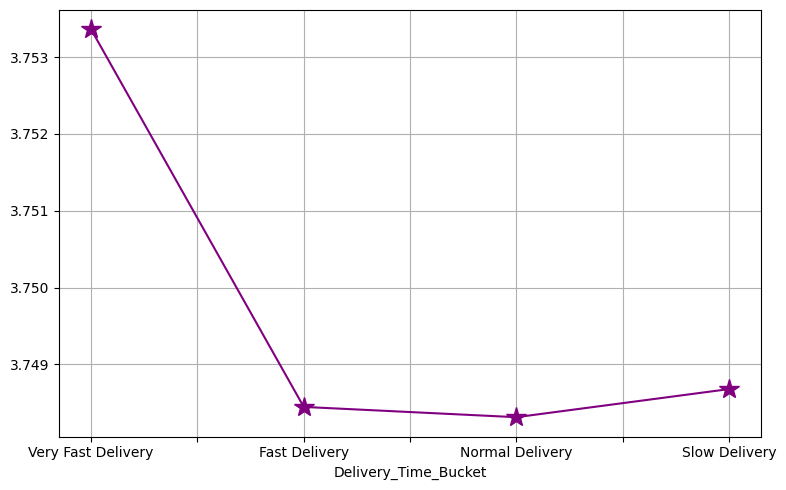

In [26]:
plt.figure(figsize = (8, 5))
bucket_avg.plot(marker = '*', markersize = 15, color = 'purple')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Q7. What is the most popular Category on swiggy instamart, for the people of age between 30-40, in Mumbai?

In [27]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Rounded_Rating,Round_delivery_time,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19.182,11.97,12,Dairy,Wallet,2.1,1,3.2,2,19,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,19.644,12.74,10,Snacks,Cash on Delivery,2.3,0,3.2,2,20,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,16.910,4.85,19,Personal Care,Cash on Delivery,3.3,0,3.8,3,17,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,5.864,6.44,2,Dairy,Credit Card,5.0,1,5.0,5,6,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12.470,2.45,13,Household,Wallet,3.7,0,4.8,4,12,Fast Delivery


In [28]:
df_pc = df[(df['Company'] == 'Swiggy Instamart')
    & ((df['Customer_Age'] >= 30) & (df['Customer_Age']<40)) 
    & (df['City']== 'Mumbai')]

In [29]:
#Most popular product category

df_pc['Product_Category'].value_counts()

Product_Category
Dairy                  368
Fruits & Vegetables    343
Groceries              341
Household              340
Snacks                 329
Personal Care          305
Beverages              299
Name: count, dtype: int64

#### Q8. Which cities should these company expand into based on performance?

In [30]:
city_perf = df.groupby(['Company', 'City']).agg(
    Total_Order = ('Order_ID', 'count'), 
    Avg_Rating = ('Customer_Rating', 'mean'),
    Avg_Delivery_Time = ('Delivery_Time_Min', 'mean'),
    Total_Revenue = ('Order_Value', 'sum')
).reset_index()

In [31]:
# Filtering Best Cities Based on given Condition

best_cities = city_perf[
    (city_perf['Avg_Rating']>= 3.5) &
    (city_perf['Avg_Delivery_Time']  <= 15) &
    (city_perf['Total_Order']> city_perf['Total_Order'].median())
]

In [32]:
best_cities

,Company,City,Total_Order,Avg_Rating,Avg_Delivery_Time,Total_Revenue
24,Blinkit,Amritsar,9932,3.563903,14.193917,6006361
26,Blinkit,Chennai,9876,3.554836,14.131362,5921870
28,Blinkit,Gurgaon,10078,3.549614,14.197823,7374774
32,Blinkit,Kolkata,10004,3.540146,14.131322,6003384
35,Blinkit,Pune,9908,3.551583,14.162116,5930415
85,Zepto,Bengluru,9971,3.610873,9.197024,6041668


In [33]:
best_cities[['Company', 'City']]

,Company,City
24,Blinkit,Amritsar
26,Blinkit,Chennai
28,Blinkit,Gurgaon
32,Blinkit,Kolkata
35,Blinkit,Pune
85,Zepto,Bengluru


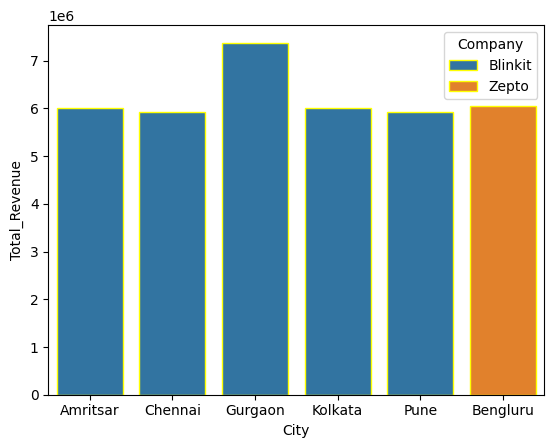

In [34]:
sns.barplot(data = best_cities, x = 'City', y = 'Total_Revenue', hue = 'Company', edgecolor = 'yellow')
plt.legend(title = 'Company', bbox_to_anchor = (1,1))
plt.show()

#### Q9. Are discounts increasing order volume or just reducing revenue.

In [35]:
df['Discount_Applied'].value_counts()

Discount_Applied
0    567906
1    379846
Name: count, dtype: int64

In [36]:
# Group Data - Calculate average order value
dis_order_val = df.groupby('Discount_Applied')['Order_Value'].mean()
dis_order_val

Discount_Applied
0    476.417152
1    712.190830
Name: Order_Value, dtype: float64

In [37]:
dis_items_count = df.groupby('Discount_Applied')['Items_Count'].sum()
dis_items_count

Discount_Applied
0    5854258
1    3920185
Name: Items_Count, dtype: int64

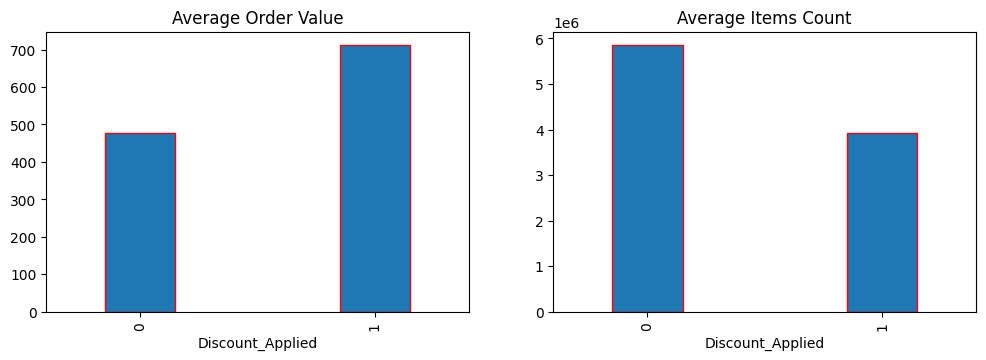

In [38]:
plt.figure(figsize = (12,8))
plt.subplot(2,2,1)
dis_order_val.plot(kind = 'bar', width = 0.3, edgecolor = 'red')
plt.title("Average Order Value")
plt.subplot(2,2,2)
dis_items_count.plot(kind = 'bar', width = 0.3, edgecolor = 'red')
plt.title("Average Items Count")
plt.show()

#### Q10. Which company has the highest Operational Effeciency (Delivery Time vs Order Volume)

In [39]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Rounded_Rating,Round_delivery_time,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19.182,11.97,12,Dairy,Wallet,2.1,1,3.2,2,19,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,19.644,12.74,10,Snacks,Cash on Delivery,2.3,0,3.2,2,20,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,16.910,4.85,19,Personal Care,Cash on Delivery,3.3,0,3.8,3,17,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,5.864,6.44,2,Dairy,Credit Card,5.0,1,5.0,5,6,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12.470,2.45,13,Household,Wallet,3.7,0,4.8,4,12,Fast Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947747,1999996,Big Basket,Mumbai,48,72,17.806,3.01,19,Fruits & Vegetables,Wallet,4.2,0,2.8,4,18,Fast Delivery
947748,1999997,Swiggy Instamart,Mumbai,33,1510,18.306,10.51,9,Beverages,Debit Card,4.1,1,3.5,4,18,Fast Delivery
947749,1999998,Jio Mart,Noida,29,637,17.590,2.65,6,Groceries,Cash on Delivery,3.4,0,4.6,3,18,Fast Delivery
947750,1999999,Dunzo,Pune,42,1103,12.656,7.76,12,Snacks,Wallet,4.0,1,4.5,4,13,Fast Delivery


In [43]:
company_efficiency = df.groupby('Company').agg(
    Total_Orders = ('Order_ID', 'count'),
    Avg_Delivery_Time = ('Round_delivery_time', 'mean')
).reset_index()

company_efficiency

,Company,Total_Orders,Avg_Delivery_Time
0,Amazon Now,118083,18.984155
1,Big Basket,118047,18.027345
2,Blinkit,118887,15.121771
3,Dunzo,118463,14.177060
4,Flipkart Minutes,118965,17.045080
5,Jio Mart,118267,23.013224
6,Swiggy Instamart,118475,16.072690
7,Zepto,118565,9.644313


In [52]:
# Normalize values for fair comparison

from sklearn.preprocessing import MinMaxScaler

# Scaling both columns to the same range (0 to 1 ) so that they can be fairly compared and combined

scaler = MinMaxScaler() #Crete a scaling object
company_efficiency[['Total_Orders_Scaled', 'Avg_Delivery_Time_Scaled']] = scaler.fit_transform(company_efficiency[['Total_Orders', 'Avg_Delivery_Time']]
    )

In [53]:
company_efficiency

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled
0,Amazon Now,118083,18.984155,0.039216,0.698624
1,Big Basket,118047,18.027345,0.000000,0.627054
2,Blinkit,118887,15.121771,0.915033,0.409716
3,Dunzo,118463,14.177060,0.453159,0.339051
4,Flipkart Minutes,118965,17.045080,1.000000,0.553580
5,Jio Mart,118267,23.013224,0.239651,1.000000
6,Swiggy Instamart,118475,16.072690,0.466231,0.480845
7,Zepto,118565,9.644313,0.564270,0.000000


In [55]:
# EFficiency Score (Higher orders, lower time)

company_efficiency['Efficiency_Score'] = company_efficiency['Total_Orders_Scaled'] - company_efficiency['Avg_Delivery_Time_Scaled']

company_efficiency

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled,Efficiency_Score
0,Amazon Now,118083,18.984155,0.039216,0.698624,-0.659408
1,Big Basket,118047,18.027345,0.000000,0.627054,-0.627054
2,Blinkit,118887,15.121771,0.915033,0.409716,0.505317
3,Dunzo,118463,14.177060,0.453159,0.339051,0.114108
4,Flipkart Minutes,118965,17.045080,1.000000,0.553580,0.446420
5,Jio Mart,118267,23.013224,0.239651,1.000000,-0.760349
6,Swiggy Instamart,118475,16.072690,0.466231,0.480845,-0.014614
7,Zepto,118565,9.644313,0.564270,0.000000,0.564270


In [58]:
# Sort by best efficiency

eff = company_efficiency.sort_values(by = 'Efficiency_Score', ascending = False)
eff

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled,Efficiency_Score
7,Zepto,118565,9.644313,0.564270,0.000000,0.564270
2,Blinkit,118887,15.121771,0.915033,0.409716,0.505317
4,Flipkart Minutes,118965,17.045080,1.000000,0.553580,0.446420
3,Dunzo,118463,14.177060,0.453159,0.339051,0.114108
6,Swiggy Instamart,118475,16.072690,0.466231,0.480845,-0.014614
1,Big Basket,118047,18.027345,0.000000,0.627054,-0.627054
0,Amazon Now,118083,18.984155,0.039216,0.698624,-0.659408
5,Jio Mart,118267,23.013224,0.239651,1.000000,-0.760349


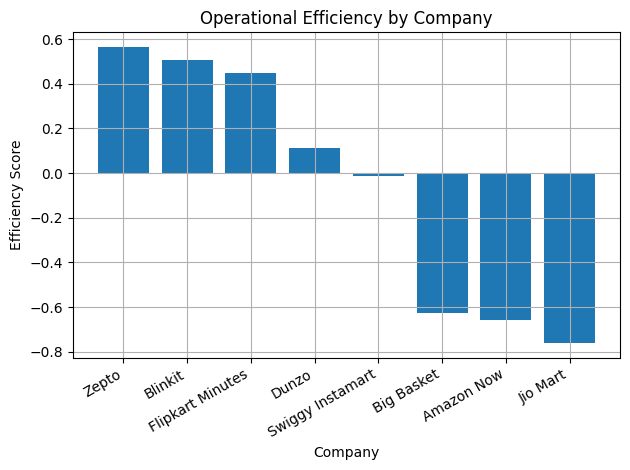

In [62]:
plt.bar(eff['Company'], eff['Efficiency_Score'])

plt.xlabel("Company")
plt.ylabel("Efficiency Score")
plt.title("Operational Efficiency by Company")
plt.xticks(rotation = 30, ha = 'right')

plt.grid(True)
plt.tight_layout()
plt.show()

In [74]:
 # Use plotly library - Scatter bubble plot

import plotly.express as px

# Create positive bubble size
min_eff = eff['Efficiency_Score'].min()
eff['Bubble_Size'] = eff['Efficiency_Score'] - min_eff + 0.1

#Plot
fig = px.scatter(eff, x = "Total_Orders", y = 'Avg_Delivery_Time', size = 'Bubble_Size', color = 'Company', text = 'Company'
                , title = "Operational Efficiency of Quick Commerce Platforms",
                hover_data = {'Total_Orders': True, "Avg_Delivery_Time": ":.2f", 'Efficiency_Score': ':.3f'},
                size_max = 40)
fig.update_traces(textposition = 'middle center')
fig.update_layout(
    template = 'plotly_dark', 
    height = 600
)
fig.show()

In [71]:
import plotly.io as pio
pio.renderers.default = 'notebook'



## Mini Dashboard

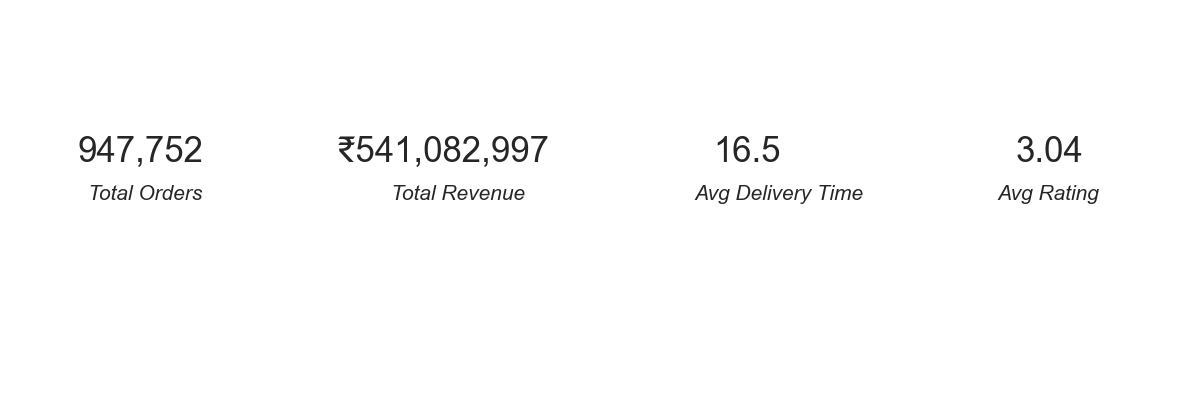

In [94]:
#create layout for dashboard

fig = plt.figure(figsize = (12, 12))
sns.set_style('whitegrid')

#---------------
#KPI calculations
#---------------

total_orders = df['Order_ID'].count()
total_revenue = df['Order_Value'].sum()
avg_delivery_time = round(df['Delivery_Time_Min'].mean(),2)
avg_rating = round(df['Customer_Rating'].mean(),2)

#------------
#KPI Cards
#------------

plt.subplot2grid((3,4), (0,0))
plt.axis('off')
plt.text(0.5, 0.6, f"{total_orders:,}", fontsize = 25, ha = 'center')
plt.text(0.3, 0.5, "Total Orders", fontsize = 15, fontstyle = 'italic')

plt.subplot2grid((3,4), (0,1))
plt.axis('off')
plt.text(0.5, 0.6, f"₹{total_revenue:,}", fontsize = 25, ha = 'center')
plt.text(0.3, 0.5, "Total Revenue", fontsize = 15, fontstyle = 'italic')

plt.subplot2grid((3,4), (0,2))
plt.axis('off')
plt.text(0.5, 0.6, f"{avg_delivery_time:,}", fontsize = 25, ha = 'center')
plt.text(0.3, 0.5, "Avg Delivery Time", fontsize = 15, fontstyle = 'italic')

plt.subplot2grid((3,4), (0,3))
plt.axis('off')
plt.text(0.5, 0.6, f"{avg_rating:,}", fontsize = 25, ha = 'center')
plt.text(0.3, 0.5, "Avg Rating", fontsize = 15, fontstyle = 'italic')


plt.tight_layout()
plt.show()